# Step 2 - Feature Engineering & Data Preprocessing
### Career Progression and Promotion Gap Analysis for Retention Optimization
**Palo Alto Networks | Unified Mentor**

**What this notebook does:** Takes the raw CSV and turns it into a clean,
model-ready dataset: engineers the 4 career-progression ratios, label-
encodes text categories into numbers, removes extreme outlier records, and
saves the result for Step 3 (clustering).

**Why this matters:** Machine learning models - K-Means clustering in
particular - only understand numbers, and they're sensitive to scale and
extreme values. This notebook is the "make everything numeric, make
everything sane" bridge between raw HR data and the clustering model.

## Setup
**What:** Import libraries, turn on inline chart display, and create the
`charts` folder if it doesn't already exist.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
chart_dir = "charts"
os.makedirs(chart_dir, exist_ok=True)

df = pd.read_csv("Palo Alto Networks.csv")
print(f"Loaded raw dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Loaded raw dataset: 1470 rows x 31 columns


## 1. Feature Engineering - Career-Progression Ratios
**What:** Re-create the same four tenure-normalised ratios from Notebook 1
(this notebook is designed to run standalone, so the logic is repeated
here rather than assuming Notebook 1 already ran in this session).
**Why:** Same reasoning as before - raw year-counts aren't comparable
across employees with different tenure; ratios are.
**Expected result:** 4 new numeric columns, each roughly 0–1.

In [2]:
df["Promotion_Gap_Ratio"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsSinceLastPromotion"] / df["YearsAtCompany"]
)
df["Role_Stagnation_Index"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsInCurrentRole"] / df["YearsAtCompany"]
)
df["Training_Intensity_Score"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["TrainingTimesLastYear"] / df["YearsAtCompany"]
)
df["Manager_Stability_Indicator"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsWithCurrManager"] / df["YearsAtCompany"]
)
print("4 career-progression features engineered.")
df[["Promotion_Gap_Ratio", "Role_Stagnation_Index", "Training_Intensity_Score", "Manager_Stability_Indicator"]].head()

4 career-progression features engineered.


,Promotion_Gap_Ratio,Role_Stagnation_Index,Training_Intensity_Score,Manager_Stability_Indicator
0,0.000,0.666667,0.000,0.833333
1,0.100,0.700000,0.300,0.700000
2,0.000,0.000000,0.000,0.000000
3,0.375,0.875000,0.375,0.000000
4,1.000,1.000000,1.500,1.000000


## 2. Encode Categorical Fields
**What:** Convert text columns (Department, JobRole, Gender, etc.) into
numeric `*_Code` columns using `LabelEncoder`, which assigns each unique
category an integer (e.g. "Sales" → 2, "R&D" → 1).
**Why:** Clustering algorithms and most statistical models can't read text
directly - everything has to become a number. We **keep** the original
text columns too, so later on the Streamlit dashboard can still show
human-readable labels like "Sales" instead of "2".
**Note:** `LabelEncoder` assigns codes alphabetically, so the same category
always gets the same code on every run - the encoding is reproducible, not
random.
**Expected result:** 7 new `*_Code` columns, one per categorical field.

In [3]:
categorical_cols = ["BusinessTravel", "Department", "EducationField",
                     "Gender", "JobRole", "MaritalStatus", "OverTime"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f"{col}_Code"] = le.fit_transform(df[col].astype(str))
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Categorical fields encoded (original text columns kept alongside):")
for col in categorical_cols:
    print(f"  {col}: {len(encoders[col])} categories -> {col}_Code")

Categorical fields encoded (original text columns kept alongside):
  BusinessTravel: 3 categories -> BusinessTravel_Code
  Department: 3 categories -> Department_Code
  EducationField: 6 categories -> EducationField_Code
  Gender: 2 categories -> Gender_Code
  JobRole: 9 categories -> JobRole_Code
  MaritalStatus: 3 categories -> MaritalStatus_Code
  OverTime: 2 categories -> OverTime_Code


## 2b. Visualise Category Composition (Bar + Donut)
**What:** For two business-relevant categorical fields (Department and
Marital Status), plot a bar chart of raw counts next to a donut chart of
the same data as proportions.
**Why:** Encoding turns categories into numbers, and it's easy to lose
track of what those numbers represent. This chart is a visual "reference
key" - confirming, for example, that Department has 3 categories and
roughly what share of the workforce each holds - right before we start
treating it as `Department_Code = 0/1/2`.

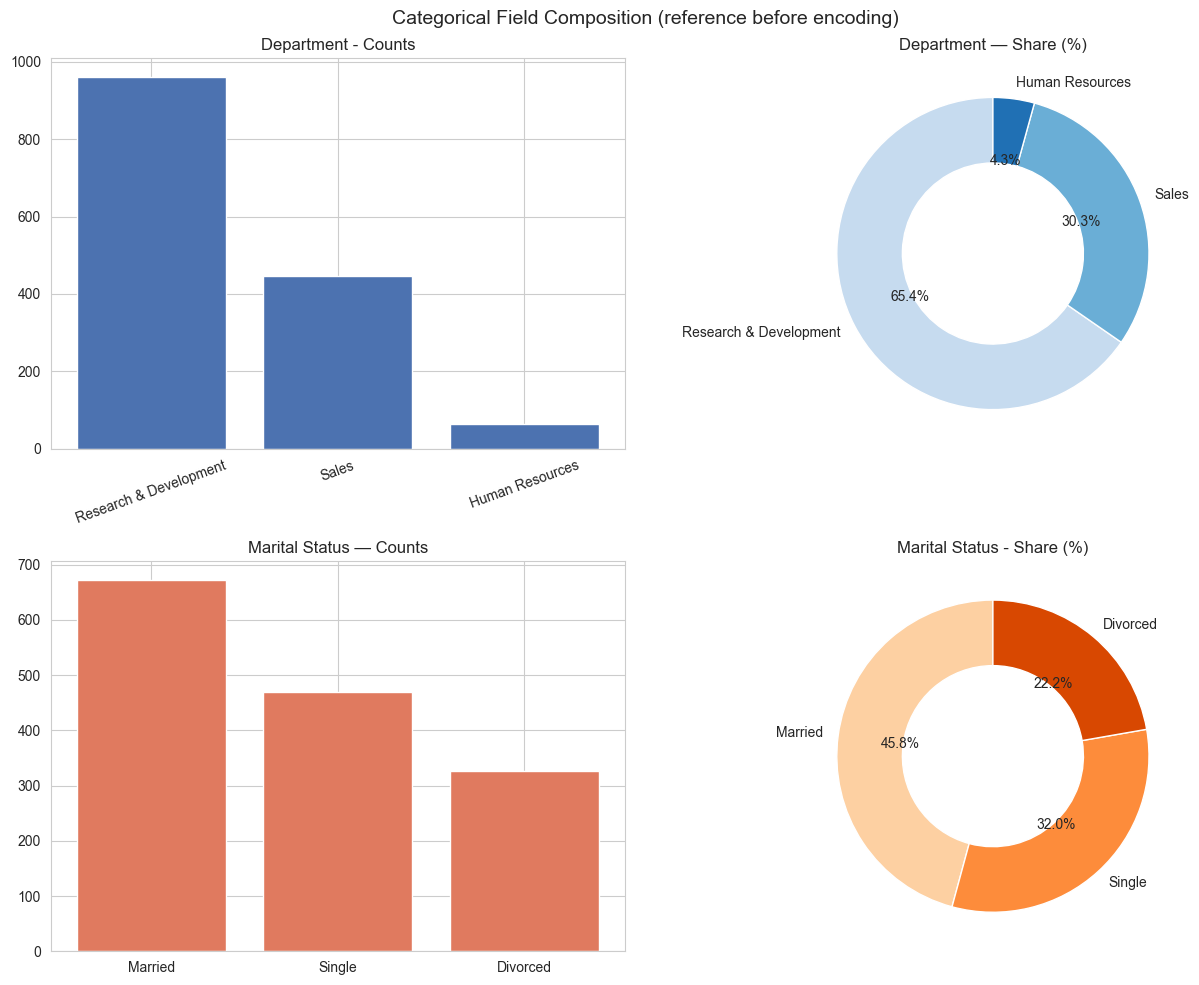

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

dept_counts = df["Department"].value_counts()
axes[0, 0].bar(dept_counts.index, dept_counts.values, color="#4C72B0")
axes[0, 0].set_title("Department - Counts")
axes[0, 0].tick_params(axis="x", rotation=20)

axes[0, 1].pie(
    dept_counts.values, labels=dept_counts.index, autopct="%1.1f%%",
    colors=sns.color_palette("Blues", len(dept_counts)), startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[0, 1].set_title("Department — Share (%)")

marital_counts = df["MaritalStatus"].value_counts()
axes[1, 0].bar(marital_counts.index, marital_counts.values, color="#E07A5F")
axes[1, 0].set_title("Marital Status — Counts")

axes[1, 1].pie(
    marital_counts.values, labels=marital_counts.index, autopct="%1.1f%%",
    colors=sns.color_palette("Oranges", len(marital_counts)), startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[1, 1].set_title("Marital Status - Share (%)")

plt.suptitle("Categorical Field Composition (reference before encoding)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig_categorical_composition.png"), dpi=150)
plt.show()

## 3. Outlier Removal (Late-Career Edge Cases)
**What:** Use the IQR (Interquartile Range) rule to detect and drop rows
with extreme values in `YearsAtCompany` or `TotalWorkingYears`.
**Why:** K-Means clustering (Step 3) measures Euclidean (straight-line)
distance between employees. A handful of very long-tenured employees
(30+ years) sit far away from everyone else in that distance space and can
pull cluster centres toward themselves, distorting the segmentation for the
other 98%+ of the workforce.
**How it works:** For each column, anything below `Q1 - k*IQR` or above
`Q3 + k*IQR` is flagged as an outlier. We use `k = 3.0` (stricter than the
conventional `k = 1.5`) so we only remove genuinely extreme edge cases, not
ordinary senior employees.
**Expected result:** A small number of rows removed (roughly 1-2% of the
dataset) - enough to stabilise clustering without meaningfully shrinking
the analysis population.

In [5]:
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

before = df.shape[0]
outlier_mask = pd.Series(False, index=df.index)
for col in ["YearsAtCompany", "TotalWorkingYears"]:
    lower, upper = iqr_bounds(df[col], k=3.0)
    outlier_mask |= (df[col] < lower) | (df[col] > upper)

df_clean = df[~outlier_mask].reset_index(drop=True)
removed = before - df_clean.shape[0]
print(f"Outlier removal: {removed} extreme late-career edge cases removed "
      f"(IQR k=3.0 on YearsAtCompany / TotalWorkingYears).")
print(f"Rows before: {before} | Rows after: {df_clean.shape[0]}")

Outlier removal: 19 extreme late-career edge cases removed (IQR k=3.0 on YearsAtCompany / TotalWorkingYears).
Rows before: 1470 | Rows after: 1451


## 3b. Visualise the Impact of Outlier Removal
**What:** A donut chart showing what share of employees were kept vs
removed, plus a before/after boxplot of `TotalWorkingYears` so you can
*see* the extreme tail disappear.
**Why:** Removing data should always be visible and justified, not a
silent step buried in code. This chart is the visual proof that we removed
a small, genuinely extreme slice - not a meaningful chunk of the workforce.

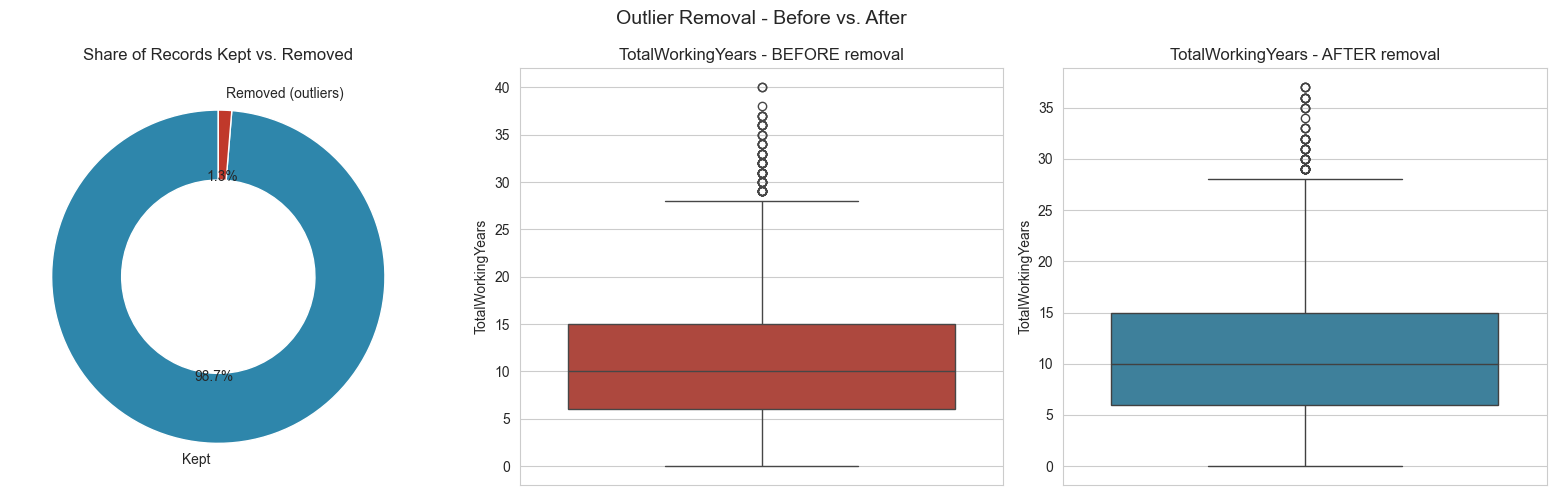

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(
    [df_clean.shape[0], removed], labels=["Kept", "Removed (outliers)"],
    autopct="%1.1f%%", colors=["#2E86AB", "#C0392B"], startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[0].set_title("Share of Records Kept vs. Removed")

sns.boxplot(y=df["TotalWorkingYears"], ax=axes[1], color="#C0392B")
axes[1].set_title("TotalWorkingYears - BEFORE removal")

sns.boxplot(y=df_clean["TotalWorkingYears"], ax=axes[2], color="#2E86AB")
axes[2].set_title("TotalWorkingYears - AFTER removal")

plt.suptitle("Outlier Removal - Before vs. After", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig_outlier_removal_impact.png"), dpi=150)
plt.show()

## 4. Save the Cleaned, Feature-Engineered Dataset
**What:** Write the processed DataFrame to `Cleaned_Engineered_HR_Data.csv`.
**Why:** Step 3 (clustering) reads this file as its starting point, keeping
each notebook's responsibility separate and easy to re-run independently.

In [7]:
output_path = "Cleaned_Engineered_HR_Data.csv"
df_clean.to_csv(output_path, index=False)
print(f"Success! Cleaned & engineered dataset saved at:\n{os.path.abspath(output_path)}")
print(f"Charts saved to: {os.path.abspath(chart_dir)}")

Success! Cleaned & engineered dataset saved at:
d:\INTERNSHIP PROJECTS\UNIFIED MENTOR WORK\Replacemnet files\final_delivery_v3\Cleaned_Engineered_HR_Data.csv
Charts saved to: d:\INTERNSHIP PROJECTS\UNIFIED MENTOR WORK\Replacemnet files\final_delivery_v3\charts


## Summary
We engineered the 4 career-progression ratios, encoded 7 categorical
fields into numeric codes (while keeping the readable text versions too),
and removed 19 extreme outlier records using a conservative IQR rule -
visibly confirmed by the before/after boxplots above.

**Next notebook:** `3_ML_Clustering.ipynb` - clusters employees into
career-path segments, scores promotion-gap risk, and identifies retention
opportunities.